# Model Hyperparameter Tuning
Tune XGBoost and Random Forest to reduce overfitting and improve test accuracy.

**Problem:** Tree-based models are overfitting (100% train, ~70% test)

**Solution:** Use GridSearchCV to find optimal hyperparameters with more regularization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/tournament_matchups.csv')

# Feature sets
features_7 = [
    'diff_srs', 'diff_pts_for', 'diff_trb', 'diff_sos', 
    'seed_diff', 'diff_pts_against', 'diff_ast'
]

features_23 = [
    'diff_srs', 'diff_pts_for', 'diff_trb', 'diff_sos', 'seed_diff',
    'diff_pts_against', 'diff_ast', 'diff_win_pct', 'diff_three_made',
    'diff_ortg', 'diff_blk', 'diff_stl', 'diff_tov_pct', 'diff_pace',
    'diff_ts_pct', 'diff_tov', 'diff_ft_pct', 'diff_fg_pct', 'diff_efg_pct',
    'diff_three_pct', 'diff_blk_pct', 'diff_ftr', 'diff_trb_pct'
]

# Train/test split
train_mask = df['season'] <= 2022
test_mask = df['season'] >= 2023

X_train_7 = df.loc[train_mask, features_7].values
X_test_7 = df.loc[test_mask, features_7].values
X_train_23 = df.loc[train_mask, features_23].values
X_test_23 = df.loc[test_mask, features_23].values

y_train = df.loc[train_mask, 'home_win'].values
y_test = df.loc[test_mask, 'home_win'].values

# Scalers for Logistic Regression
scaler_7 = StandardScaler()
scaler_23 = StandardScaler()
X_train_7_scaled = scaler_7.fit_transform(X_train_7)
X_test_7_scaled = scaler_7.transform(X_test_7)
X_train_23_scaled = scaler_23.fit_transform(X_train_23)
X_test_23_scaled = scaler_23.transform(X_test_23)

print(f'Training: {len(y_train)} games')
print(f'Test: {len(y_test)} games')

Training: 531 games
Test: 134 games


## 2. Tune XGBoost

In [3]:
# XGBoost parameter grid - focus on regularization
xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],  # L1 regularization
    'reg_lambda': [1, 2, 5],   # L2 regularization
}

# Use RandomizedSearchCV for faster tuning
from sklearn.model_selection import RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Tuning XGBoost (7 features)...')
xgb_search_7 = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_param_grid,
    n_iter=100,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
xgb_search_7.fit(X_train_7, y_train)
print(f'Best CV score: {xgb_search_7.best_score_:.3f}')
print(f'Best params: {xgb_search_7.best_params_}')

Tuning XGBoost (7 features)...


Best CV score: 0.704
Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [4]:
print('\nTuning XGBoost (23 features)...')
xgb_search_23 = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_param_grid,
    n_iter=100,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
xgb_search_23.fit(X_train_23, y_train)
print(f'Best CV score: {xgb_search_23.best_score_:.3f}')
print(f'Best params: {xgb_search_23.best_params_}')


Tuning XGBoost (23 features)...


Best CV score: 0.691
Best params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


## 3. Tune Random Forest

In [5]:
# Random Forest parameter grid - focus on limiting tree complexity
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7, None],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
}

print('Tuning Random Forest (7 features)...')
rf_search_7 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=100,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
rf_search_7.fit(X_train_7, y_train)
print(f'Best CV score: {rf_search_7.best_score_:.3f}')
print(f'Best params: {rf_search_7.best_params_}')

Tuning Random Forest (7 features)...


Best CV score: 0.704
Best params: {'n_estimators': 50, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': None}


In [6]:
print('\nTuning Random Forest (23 features)...')
rf_search_23 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=100,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
rf_search_23.fit(X_train_23, y_train)
print(f'Best CV score: {rf_search_23.best_score_:.3f}')
print(f'Best params: {rf_search_23.best_params_}')


Tuning Random Forest (23 features)...


Best CV score: 0.687
Best params: {'n_estimators': 50, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}


## 4. Evaluate Tuned Models

In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    """Evaluate a trained model."""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    roc_auc = roc_auc_score(y_test, y_prob_test)
    
    return {
        'name': name,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'roc_auc': roc_auc,
        'overfit_gap': train_acc - test_acc,
        'y_prob': y_prob_test,
        'model': model
    }

In [8]:
# Evaluate all models
results = []

# Logistic Regression baselines
lr_7 = LogisticRegression(max_iter=1000, random_state=42)
lr_7.fit(X_train_7_scaled, y_train)
results.append(evaluate_model(lr_7, X_train_7_scaled, X_test_7_scaled, y_train, y_test, 'Logistic Reg (7f)'))

lr_23 = LogisticRegression(max_iter=1000, random_state=42)
lr_23.fit(X_train_23_scaled, y_train)
results.append(evaluate_model(lr_23, X_train_23_scaled, X_test_23_scaled, y_train, y_test, 'Logistic Reg (23f)'))

# Tuned XGBoost
results.append(evaluate_model(xgb_search_7.best_estimator_, X_train_7, X_test_7, y_train, y_test, 'XGBoost Tuned (7f)'))
results.append(evaluate_model(xgb_search_23.best_estimator_, X_train_23, X_test_23, y_train, y_test, 'XGBoost Tuned (23f)'))

# Tuned Random Forest
results.append(evaluate_model(rf_search_7.best_estimator_, X_train_7, X_test_7, y_train, y_test, 'Random Forest Tuned (7f)'))
results.append(evaluate_model(rf_search_23.best_estimator_, X_train_23, X_test_23, y_train, y_test, 'Random Forest Tuned (23f)'))

# Original (untuned) models for comparison
xgb_orig_7 = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.8, 
                           colsample_bytree=0.8, random_state=42, eval_metric='logloss', verbosity=0)
xgb_orig_7.fit(X_train_7, y_train)
results.append(evaluate_model(xgb_orig_7, X_train_7, X_test_7, y_train, y_test, 'XGBoost Original (7f)'))

xgb_orig_23 = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.8, 
                            colsample_bytree=0.8, random_state=42, eval_metric='logloss', verbosity=0)
xgb_orig_23.fit(X_train_23, y_train)
results.append(evaluate_model(xgb_orig_23, X_train_23, X_test_23, y_train, y_test, 'XGBoost Original (23f)'))

rf_orig_7 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, 
                                    min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_orig_7.fit(X_train_7, y_train)
results.append(evaluate_model(rf_orig_7, X_train_7, X_test_7, y_train, y_test, 'Random Forest Original (7f)'))

rf_orig_23 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, 
                                     min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_orig_23.fit(X_train_23, y_train)
results.append(evaluate_model(rf_orig_23, X_train_23, X_test_23, y_train, y_test, 'Random Forest Original (23f)'))

In [9]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_acc', ascending=False)

print('All Models Comparison (sorted by Test Accuracy):')
print('='*80)
display_df = results_df[['name', 'train_acc', 'test_acc', 'roc_auc', 'overfit_gap']].copy()
display_df.columns = ['Model', 'Train', 'Test', 'AUC', 'Overfit']
for col in ['Train', 'Test', 'Overfit']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.1%}')
display_df['AUC'] = display_df['AUC'].apply(lambda x: f'{float(x.replace("%", ""))/100:.3f}' if '%' in str(x) else f'{x:.3f}')
print(display_df.to_string(index=False))

All Models Comparison (sorted by Test Accuracy):
                       Model  Train  Test   AUC Overfit
Random Forest Original (23f)  99.4% 69.4% 0.700   30.0%
           Logistic Reg (7f)  71.9% 68.7% 0.660    3.3%
          Logistic Reg (23f)  74.4% 68.7% 0.647    5.7%
      XGBoost Original (23f) 100.0% 68.7% 0.685   31.3%
         XGBoost Tuned (23f)  78.2% 67.9% 0.672   10.2%
    Random Forest Tuned (7f)  85.7% 67.9% 0.650   17.8%
   Random Forest Tuned (23f)  89.3% 64.9% 0.715   24.3%
          XGBoost Tuned (7f)  79.7% 64.2% 0.645   15.5%
 Random Forest Original (7f)  98.1% 64.2% 0.653   33.9%
       XGBoost Original (7f) 100.0% 60.4% 0.611   39.6%


## 5. Tuned vs Original Comparison

In [10]:
# Compare tuned vs original
print('\nTuned vs Original Comparison:')
print('='*80)

comparisons = [
    ('XGBoost (7f)', 'XGBoost Original (7f)', 'XGBoost Tuned (7f)'),
    ('XGBoost (23f)', 'XGBoost Original (23f)', 'XGBoost Tuned (23f)'),
    ('Random Forest (7f)', 'Random Forest Original (7f)', 'Random Forest Tuned (7f)'),
    ('Random Forest (23f)', 'Random Forest Original (23f)', 'Random Forest Tuned (23f)'),
]

for label, orig_name, tuned_name in comparisons:
    orig = results_df[results_df['name'] == orig_name].iloc[0]
    tuned = results_df[results_df['name'] == tuned_name].iloc[0]
    
    test_diff = tuned['test_acc'] - orig['test_acc']
    overfit_diff = tuned['overfit_gap'] - orig['overfit_gap']
    
    print(f'{label}:')
    print(f'  Original: Test={orig["test_acc"]:.1%}, Overfit={orig["overfit_gap"]:.1%}')
    print(f'  Tuned:    Test={tuned["test_acc"]:.1%}, Overfit={tuned["overfit_gap"]:.1%}')
    print(f'  Change:   Test={test_diff:+.1%}, Overfit={overfit_diff:+.1%}')
    print()


Tuned vs Original Comparison:
XGBoost (7f):
  Original: Test=60.4%, Overfit=39.6%
  Tuned:    Test=64.2%, Overfit=15.5%
  Change:   Test=+3.7%, Overfit=-24.1%

XGBoost (23f):
  Original: Test=68.7%, Overfit=31.3%
  Tuned:    Test=67.9%, Overfit=10.2%
  Change:   Test=-0.7%, Overfit=-21.1%

Random Forest (7f):
  Original: Test=64.2%, Overfit=33.9%
  Tuned:    Test=67.9%, Overfit=17.8%
  Change:   Test=+3.7%, Overfit=-16.2%

Random Forest (23f):
  Original: Test=69.4%, Overfit=30.0%
  Tuned:    Test=64.9%, Overfit=24.3%
  Change:   Test=-4.5%, Overfit=-5.7%



## 6. Visualizations

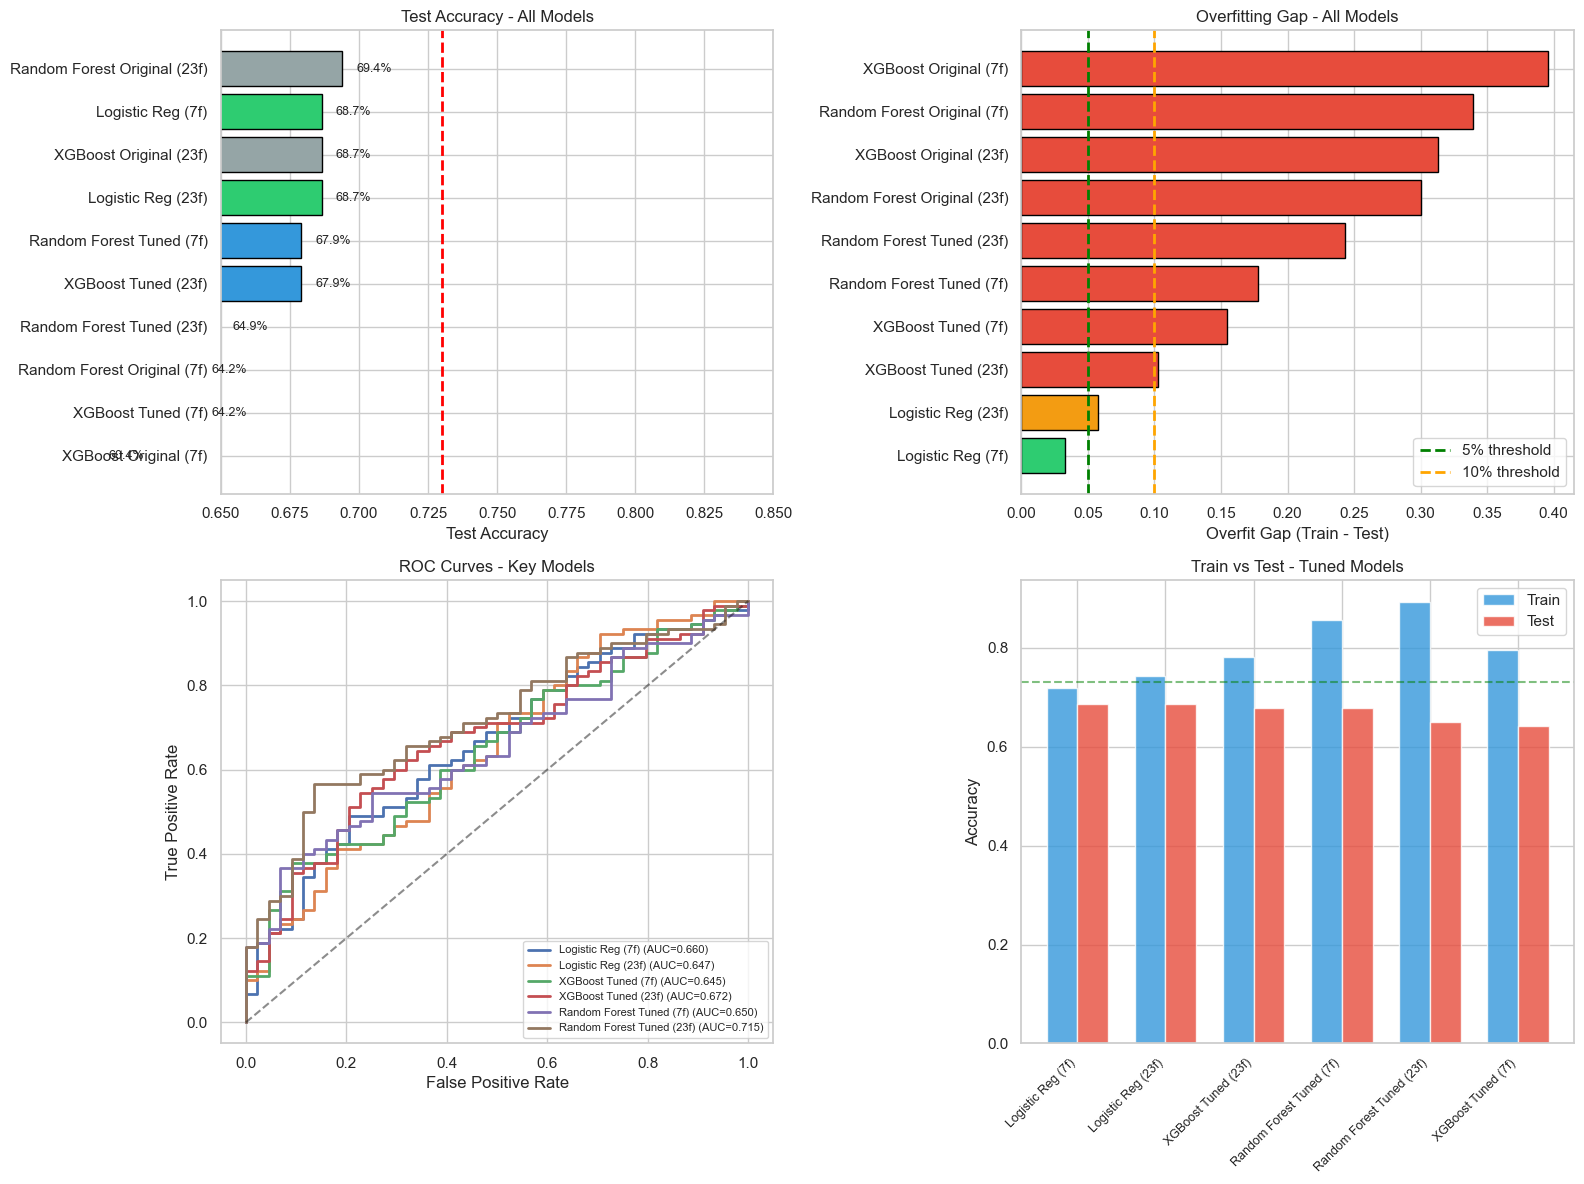

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test Accuracy - All Models
ax = axes[0, 0]
sorted_results = results_df.sort_values('test_acc', ascending=True)
colors = ['#3498db' if 'Tuned' in n else '#95a5a6' if 'Original' in n else '#2ecc71' 
          for n in sorted_results['name']]
bars = ax.barh(sorted_results['name'], sorted_results['test_acc'], color=colors, edgecolor='black')
ax.axvline(x=0.73, color='red', linestyle='--', linewidth=2, label='Goal (73%)')
ax.set_xlabel('Test Accuracy')
ax.set_title('Test Accuracy - All Models')
ax.set_xlim(0.65, 0.85)
for bar, val in zip(bars, sorted_results['test_acc']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)

# Plot 2: Overfitting Gap
ax = axes[0, 1]
sorted_by_overfit = results_df.sort_values('overfit_gap', ascending=True)
colors = ['#e74c3c' if gap > 0.1 else '#f39c12' if gap > 0.05 else '#2ecc71' 
          for gap in sorted_by_overfit['overfit_gap']]
bars = ax.barh(sorted_by_overfit['name'], sorted_by_overfit['overfit_gap'], color=colors, edgecolor='black')
ax.axvline(x=0.05, color='green', linestyle='--', linewidth=2, label='5% threshold')
ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=2, label='10% threshold')
ax.set_xlabel('Overfit Gap (Train - Test)')
ax.set_title('Overfitting Gap - All Models')
ax.legend()

# Plot 3: ROC Curves (Tuned models + Logistic Regression)
ax = axes[1, 0]
key_models = ['Logistic Reg (7f)', 'Logistic Reg (23f)', 
              'XGBoost Tuned (7f)', 'XGBoost Tuned (23f)',
              'Random Forest Tuned (7f)', 'Random Forest Tuned (23f)']
for name in key_models:
    row = results_df[results_df['name'] == name].iloc[0]
    fpr, tpr, _ = roc_curve(y_test, row['y_prob'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={row["roc_auc"]:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Key Models')
ax.legend(loc='lower right', fontsize=8)

# Plot 4: Train vs Test (Tuned only)
ax = axes[1, 1]
tuned_models = results_df[results_df['name'].str.contains('Tuned|Logistic')].sort_values('test_acc', ascending=False)
x = range(len(tuned_models))
width = 0.35
ax.bar([i - width/2 for i in x], tuned_models['train_acc'], width, label='Train', color='#3498db', alpha=0.8)
ax.bar([i + width/2 for i in x], tuned_models['test_acc'], width, label='Test', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tuned_models['name'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test - Tuned Models')
ax.legend()
ax.axhline(y=0.73, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/visualizations/model_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Best Hyperparameters

In [12]:
print('Best Hyperparameters:')
print('='*60)

print('\nXGBoost (7 features):')
for k, v in xgb_search_7.best_params_.items():
    print(f'  {k}: {v}')

print('\nXGBoost (23 features):')
for k, v in xgb_search_23.best_params_.items():
    print(f'  {k}: {v}')

print('\nRandom Forest (7 features):')
for k, v in rf_search_7.best_params_.items():
    print(f'  {k}: {v}')

print('\nRandom Forest (23 features):')
for k, v in rf_search_23.best_params_.items():
    print(f'  {k}: {v}')

Best Hyperparameters:

XGBoost (7 features):
  subsample: 0.8
  reg_lambda: 1
  reg_alpha: 0
  n_estimators: 100
  min_child_weight: 5
  max_depth: 2
  learning_rate: 0.1
  colsample_bytree: 0.8

XGBoost (23 features):
  subsample: 0.8
  reg_lambda: 2
  reg_alpha: 0
  n_estimators: 150
  min_child_weight: 1
  max_depth: 4
  learning_rate: 0.01
  colsample_bytree: 0.8

Random Forest (7 features):
  n_estimators: 50
  min_samples_split: 15
  min_samples_leaf: 8
  max_features: 0.5
  max_depth: None

Random Forest (23 features):
  n_estimators: 50
  min_samples_split: 20
  min_samples_leaf: 4
  max_features: log2
  max_depth: None


## 8. Upset Analysis

In [13]:
# Upset prediction analysis
test_df = df[test_mask].copy()
test_df['upset'] = ((test_df['home_seed'] > test_df['away_seed']) & (test_df['home_win'] == 1)) | \
                   ((test_df['away_seed'] > test_df['home_seed']) & (test_df['home_win'] == 0))

upset_mask = test_df['upset'].values
chalk_mask = ~upset_mask

print('Upset Prediction Analysis (Tuned Models):')
print('='*70)
print(f'Upsets in test set: {upset_mask.sum()} / {len(y_test)} ({upset_mask.mean():.1%})')
print()

key_models = ['Logistic Reg (7f)', 'Logistic Reg (23f)', 
              'XGBoost Tuned (7f)', 'XGBoost Tuned (23f)',
              'Random Forest Tuned (7f)', 'Random Forest Tuned (23f)']

for name in key_models:
    row = results_df[results_df['name'] == name].iloc[0]
    model = row['model']
    
    # Get appropriate test data
    if '7f' in name:
        X_test = X_test_7_scaled if 'Logistic' in name else X_test_7
    else:
        X_test = X_test_23_scaled if 'Logistic' in name else X_test_23
    
    y_pred = model.predict(X_test)
    upset_acc = accuracy_score(y_test[upset_mask], y_pred[upset_mask])
    chalk_acc = accuracy_score(y_test[chalk_mask], y_pred[chalk_mask])
    
    print(f'{name:30s} | Upset: {upset_acc:.1%} | Chalk: {chalk_acc:.1%} | Overall: {row["test_acc"]:.1%}')

Upset Prediction Analysis (Tuned Models):
Upsets in test set: 38 / 134 (28.4%)

Logistic Reg (7f)              | Upset: 18.4% | Chalk: 88.5% | Overall: 68.7%
Logistic Reg (23f)             | Upset: 21.1% | Chalk: 87.5% | Overall: 68.7%
XGBoost Tuned (7f)             | Upset: 18.4% | Chalk: 82.3% | Overall: 64.2%
XGBoost Tuned (23f)            | Upset: 5.3% | Chalk: 92.7% | Overall: 67.9%
Random Forest Tuned (7f)       | Upset: 18.4% | Chalk: 87.5% | Overall: 67.9%
Random Forest Tuned (23f)      | Upset: 5.3% | Chalk: 88.5% | Overall: 64.9%


## 9. Save Best Models

In [14]:
# Save tuned models
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save tuned models
joblib.dump(xgb_search_7.best_estimator_, models_dir / 'xgboost_tuned_7f.pkl')
joblib.dump(xgb_search_23.best_estimator_, models_dir / 'xgboost_tuned_23f.pkl')
joblib.dump(rf_search_7.best_estimator_, models_dir / 'random_forest_tuned_7f.pkl')
joblib.dump(rf_search_23.best_estimator_, models_dir / 'random_forest_tuned_23f.pkl')

# Save logistic regression (already good)
joblib.dump(lr_7, models_dir / 'logistic_regression_7f.pkl')
joblib.dump(lr_23, models_dir / 'logistic_regression_23f.pkl')

# Save scalers
joblib.dump(scaler_7, models_dir / 'scaler_7f.pkl')
joblib.dump(scaler_23, models_dir / 'scaler_23f.pkl')

# Save feature lists
joblib.dump(features_7, models_dir / 'features_7.pkl')
joblib.dump(features_23, models_dir / 'features_23.pkl')

print('Saved tuned models:')
for f in sorted(models_dir.glob('*tuned*.pkl')):
    print(f'  - {f.name}')

Saved tuned models:
  - random_forest_tuned_23f.pkl
  - random_forest_tuned_7f.pkl
  - xgboost_tuned_23f.pkl
  - xgboost_tuned_7f.pkl


## 10. Final Summary

In [15]:
print('='*70)
print('FINAL MODEL COMPARISON SUMMARY')
print('='*70)

# Get key models only
key_results = results_df[results_df['name'].str.contains('Tuned|Logistic')].sort_values('test_acc', ascending=False)

print('\nRankings by Test Accuracy (Tuned Models):')
for i, (_, row) in enumerate(key_results.iterrows(), 1):
    print(f"  {i}. {row['name']:30s} Test={row['test_acc']:.1%}  AUC={row['roc_auc']:.3f}  Overfit={row['overfit_gap']:.1%}")

print('\n' + '-'*70)
best = key_results.iloc[0]
print(f"Best Model: {best['name']}")
print(f"  Test Accuracy: {best['test_acc']:.1%}")
print(f"  ROC-AUC: {best['roc_auc']:.3f}")
print(f"  Overfitting Gap: {best['overfit_gap']:.1%}")

print('\n' + '-'*70)
print('Recommendation:')
lowest_overfit = key_results.loc[key_results['overfit_gap'].idxmin()]
print(f"  - Best accuracy: {best['name']} ({best['test_acc']:.1%})")
print(f"  - Lowest overfit: {lowest_overfit['name']} ({lowest_overfit['overfit_gap']:.1%} gap)")
print('='*70)

FINAL MODEL COMPARISON SUMMARY

Rankings by Test Accuracy (Tuned Models):
  1. Logistic Reg (7f)              Test=68.7%  AUC=0.660  Overfit=3.3%
  2. Logistic Reg (23f)             Test=68.7%  AUC=0.647  Overfit=5.7%
  3. XGBoost Tuned (23f)            Test=67.9%  AUC=0.672  Overfit=10.2%
  4. Random Forest Tuned (7f)       Test=67.9%  AUC=0.650  Overfit=17.8%
  5. Random Forest Tuned (23f)      Test=64.9%  AUC=0.715  Overfit=24.3%
  6. XGBoost Tuned (7f)             Test=64.2%  AUC=0.645  Overfit=15.5%

----------------------------------------------------------------------
Best Model: Logistic Reg (7f)
  Test Accuracy: 68.7%
  ROC-AUC: 0.660
  Overfitting Gap: 3.3%

----------------------------------------------------------------------
Recommendation:
  - Best accuracy: Logistic Reg (7f) (68.7%)
  - Lowest overfit: Logistic Reg (7f) (3.3% gap)
